# 01. Analisi Esplorativa (EDA - ovvero investigare dataset per vederne le caratteristiche) e Preprocessing
In questo notebook carichiamo i dati grezzi, analizziamo la distribuzione delle classi e prepariamo i dati per i modelli (Scaling e PCA).

In [ ]:
import os
import sys
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Aggiungiamo il path dei moduli - per evitare di scrivere from modules.data_loader import ..
sys.path.append(os.path.abspath('modules'))

from data_loader import load_cancer_data
from preprocessing import GenePreprocessor
from visualization import (
    plot_pca_variance, 
    plot_expression_distribution, 
    plot_pca_2d, 
    plot_pca_3d, 
    plot_umap_2d, 
    plot_umap_3d
)
import umap

sns.set_theme(style='whitegrid')
SEED = 42

## 1. Caricamento Dati

In [9]:
X, y = load_cancer_data(data_path='../archive/data.csv', labels_path='../archive/labels.csv')
print(f"Dataset caricato: {X.shape[0]} campioni e {X.shape[1]} geni.")

Dataset caricato: 801 campioni e 20531 geni.


## 2. Analisi Esplorativa

### 2.1 Distribuzione delle Classi

C:\Users\gvnnp\AppData\Local\Temp\ipykernel_12336\4197083544.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='tab10', order=y.value_counts().index)


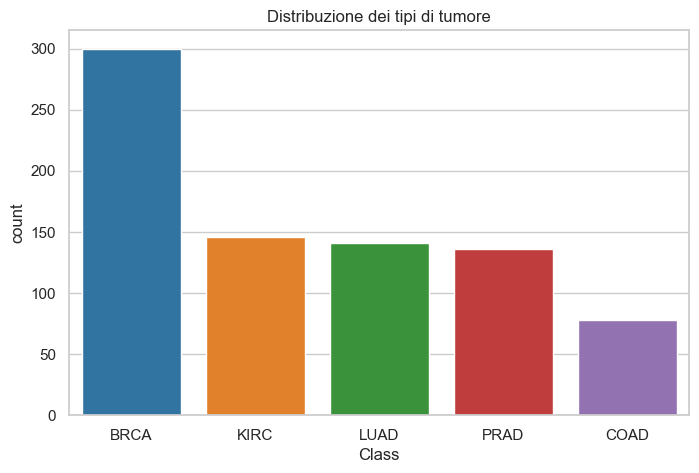

Conteggio per classe:
Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y, palette='tab10', order=y.value_counts().index)
plt.title("Distribuzione dei tipi di tumore")
plt.show()

print("Conteggio per classe:")
print(y.value_counts())

## 3. Preprocessing

### 3.1 Selezione dei geni per varianza (Variance Threshold)

In [ ]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.1) # varianza > 0.1
X_vt = vt.fit_transform(X) # calcola la varianza di ogni colonna in X - transform: Rimuove fisicamente le colonne che non superano - se in una colonna i valori sono molto simili, la elimina

variances = vt.variances_[vt.get_support()] # vt.get_support() restituisce una "maschera" di Booleani dove True indica le colonne che sono state mantenute dopo la selezione. vt.variances_ contiene la varianza di tutte le colonne di prima
features_idx = vt.get_support(indices=True) # vt.get_support(indices=True) un array di indici delle colonne mantenute
gene_names = X.columns[features_idx]

top_genes = pd.DataFrame({'Gene': gene_names, 'Variance': variances}).sort_values(by='Variance', ascending=False).head(10)
print("Top 10 Geni per Varianza:")
print(top_genes)

Top 10 Geni per Varianza:
             Gene   Variance
8908    gene_9176  44.707964
8907    gene_9175  36.316544
15062  gene_15898  34.460838
14485  gene_15301  33.417005
14756  gene_15589  31.286736
3452    gene_3540  30.549509
18414  gene_19661  30.042925
3453    gene_3541  28.685831
10839  gene_11250  26.482784
15061  gene_15897  25.986962


### 3.2 Riduzione Dimensionale (PCA al 95% varianza)
Utilizziamo la classe `GenePreprocessor` definita nei moduli per automatizzare il filtro varianza, lo scaling e la PCA.

In [ ]:
preprocessor = GenePreprocessor(variance_threshold=0.1, n_components=0.95, seed=SEED) #vedi file - sta classe contiene una pipeline intera di preparazione
X_pca, y_enc = preprocessor.fit_transform(X, y)
class_names = preprocessor.le.classes_ # ^^

print(f"Dimensioni dopo PCA: {X_pca.shape[1]} componenti (95% varianza spiegata).")

Dimensioni dopo PCA: 503 componenti (95% varianza spiegata).


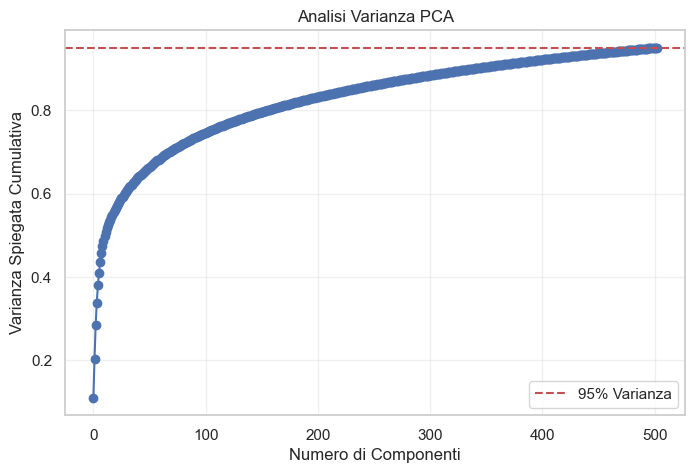

In [7]:
plot_pca_variance(preprocessor.pca)

### 3.3 Visualizzazione PCA (2D e 3D)

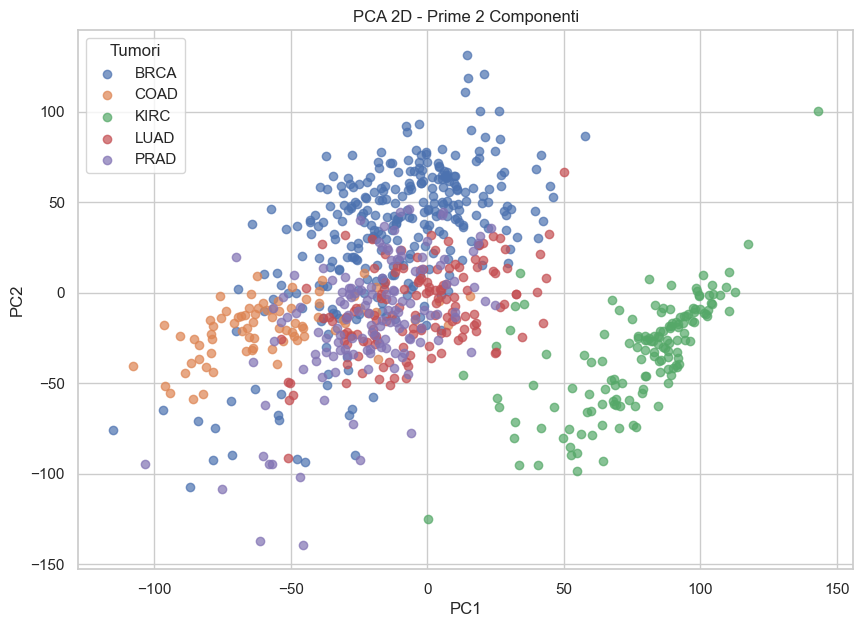

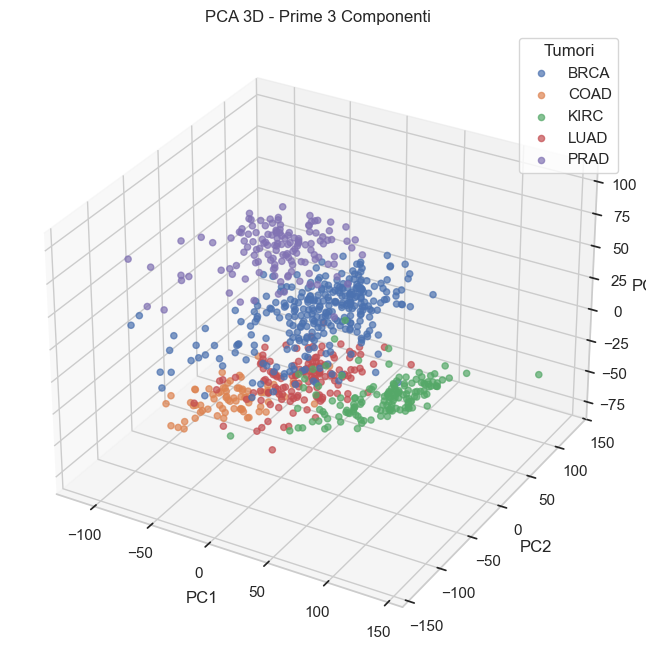

In [8]:
plot_pca_2d(X_pca, y_enc, class_names, title="PCA 2D - Prime 2 Componenti")
plot_pca_3d(X_pca, y_enc, class_names, title="PCA 3D - Prime 3 Componenti")

### 3.4 Visualizzazione UMAP (2D e 3D)

c:\Users\gvnnp\Desktop\Python\ML_Info\Prove_MachineLearning_Info\VE\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\gvnnp\Desktop\Python\ML_Info\Prove_MachineLearning_Info\VE\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


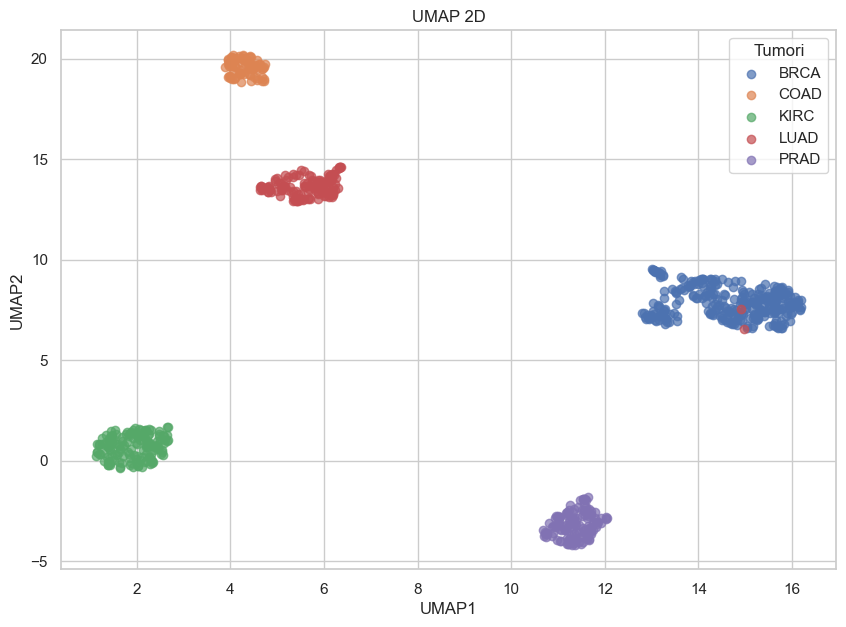

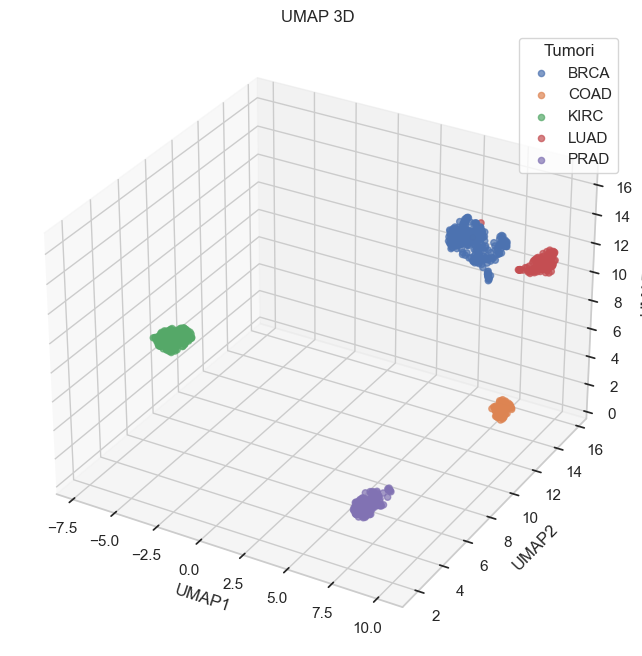

In [9]:
reducer_2d = umap.UMAP(n_components=2, random_state=SEED)
X_umap_2d = reducer_2d.fit_transform(X_pca)

reducer_3d = umap.UMAP(n_components=3, random_state=SEED)
X_umap_3d = reducer_3d.fit_transform(X_pca)

plot_umap_2d(X_umap_2d, y_enc, class_names, title="UMAP 2D")
plot_umap_3d(X_umap_3d, y_enc, class_names, title="UMAP 3D")

## 4. Salvataggio Dati Preprocessati
Salviamo i dati in formato joblib per poterli caricare velocemente nei prossimi notebook.

In [10]:
os.makedirs('data_processed', exist_ok=True)
data_to_save = {
    'X_pca': X_pca,
    'y_enc': y_enc,
    'classes': preprocessor.le.classes_
}
joblib.dump(data_to_save, 'data_processed/processed_data.joblib')
joblib.dump(preprocessor, 'models/preprocessor.joblib')

print("Dati e preprocessor salvati correttamente.")

Dati e preprocessor salvati correttamente.
